# 01 — Exploratory Data Analysis

PartnerLens segments Olist **sellers**, not customers, so this notebook explores the
raw relational schema through that lens: what links an order to a seller, where the
schema has traps that would silently distort seller-level aggregates, and how skewed
the underlying distributions are before any transformation.

Findings here justify every decision in `src/features.py` and `src/data_loader.py`.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path.cwd().parent))
from src import clustering, config, data_loader, features, profiling

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 140)


## 1. Load raw tables and check referential integrity

Every join risks silent row loss. Check before joining, not after.

In [2]:
tables, quality_report = data_loader.load_and_validate()
quality_report

{'n_orders': 99441,
 'n_order_items': 112650,
 'orphan_items': 0,
 'orders_without_items': 775,
 'duplicate_reviews_per_order': 547,
 'orders_with_review': 98673,
 'delivered_orders_missing_delivered_date': 8}

`orphan_items = 0` confirms every `order_items` row has a matching order — safe to
inner/left join without losing item rows. `orders_without_items` (775) are orders that
never got a line item (unavailable/cancelled before fulfillment); they contribute to
cancellation-rate features but must not be summed into revenue. `duplicate_reviews_per_order`
(547) and `delivered_orders_missing_delivered_date` (8) are handled explicitly in
`data_loader.dedupe_reviews` and `features.build_seller_features`.

## 2. The central limitation: orders with more than one seller

Olist is a marketplace — `order_items` is the only table linking an order to a seller, and a single `order_id` can contain items from multiple sellers.

In [3]:
mss = features.multi_seller_order_stats(tables["order_items"])
mss

{'total_orders_with_items': 98666,
 'multi_seller_orders': 1278,
 'multi_seller_orders_pct': 1.3,
 'multi_seller_revenue_pct': np.float64(1.98)}

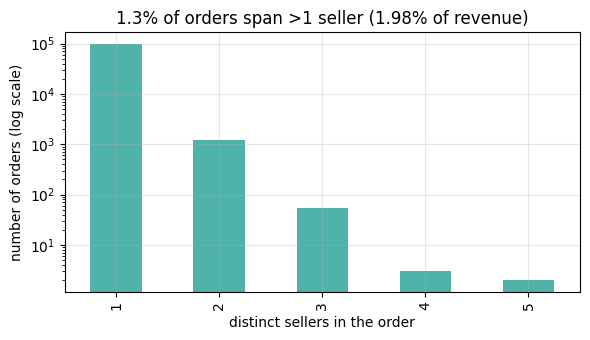

In [4]:
sellers_per_order = tables["order_items"].groupby("order_id")["seller_id"].nunique()

fig, ax = plt.subplots(figsize=(6, 3.5))
sellers_per_order.value_counts().sort_index().plot(kind="bar", ax=ax, color="#4FB3A9")
ax.set_xlabel("distinct sellers in the order")
ax.set_ylabel("number of orders (log scale)")
ax.set_yscale("log")
ax.set_title(f"{mss['multi_seller_orders_pct']}% of orders span >1 seller "
             f"({mss['multi_seller_revenue_pct']}% of revenue)")
plt.tight_layout()
plt.show()

Only **1.3% of orders** (1,278 of 98,666) involve more than one seller, carrying
**~2% of total revenue**. This is the exact blast radius of the multi-seller
review-attribution limitation described in `features.attach_review_scores`: an order's
review score is assigned to every participating seller because Olist attaches reviews
at the order level, not the line-item level. Measuring it — rather than assuming it away
— shows the distortion is marginal, not a reason to discard the feature.

## 3. Known Olist traps, quantified

In [5]:
geo_raw = tables["geolocation"]
geo_agg = data_loader.aggregate_geolocation(geo_raw)
print(f"geolocation: {len(geo_raw):,} raw rows -> {len(geo_agg):,} rows after "
      f"aggregating to one row per zip prefix ({len(geo_raw)/len(geo_agg):.1f}x cardinality)")

review_counts = tables["order_reviews"].groupby("order_id").size()
print(f"reviews: {(review_counts > 1).sum():,} orders have more than one review row "
      f"({100*(review_counts > 1).mean():.2f}%) -- deduplicated by keeping the most recent")

delivered = tables["orders"][tables["orders"]["order_status"] == "delivered"]
print(f"delivered orders missing delivered_customer_date: "
      f"{delivered['order_delivered_customer_date'].isna().sum()} of {len(delivered):,}")

geolocation: 1,000,163 raw rows -> 19,015 rows after aggregating to one row per zip prefix (52.6x cardinality)
reviews: 547 orders have more than one review row (0.55%) -- deduplicated by keeping the most recent
delivered orders missing delivered_customer_date: 8 of 96,478


## 4. Revenue and order-value skew

Monetary features are the reason `log1p` is applied before scaling in `features.add_log_features`.

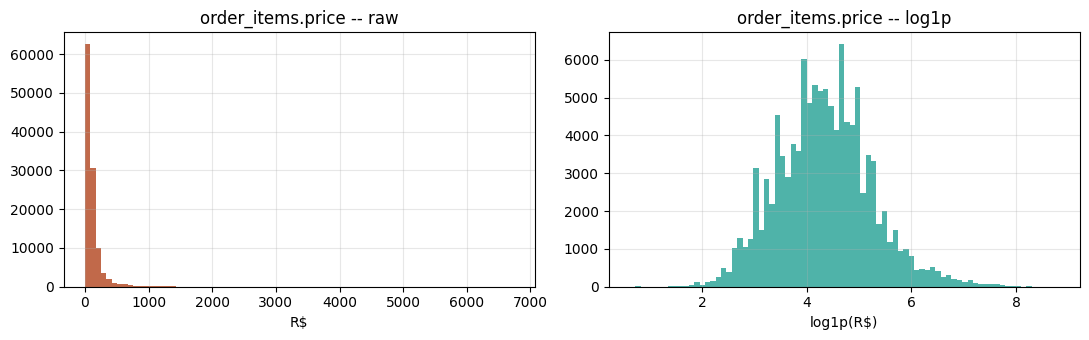

count    112650.000000
mean        120.653739
std         183.633928
min           0.850000
50%          74.990000
90%         229.800000
99%         890.000000
max        6735.000000
Name: price, dtype: float64


In [6]:
item_revenue = tables["order_items"]["price"]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].hist(item_revenue, bins=80, color="#C1694A")
axes[0].set_title("order_items.price -- raw")
axes[0].set_xlabel("R$")
axes[1].hist(np.log1p(item_revenue), bins=80, color="#4FB3A9")
axes[1].set_title("order_items.price -- log1p")
axes[1].set_xlabel("log1p(R$)")
plt.tight_layout()
plt.show()

print(item_revenue.describe(percentiles=[.5, .9, .99]))

A right-skewed distribution like this, aggregated to seller level, is exactly what would
let 5-10 outlier high-GMV sellers dominate Euclidean distance in K-Means if left untransformed.

## 5. Review score is bimodal, not normal

This is why `features.build_seller_features` uses a *rate* (share of orders scoring ≤2) rather than the mean review score.

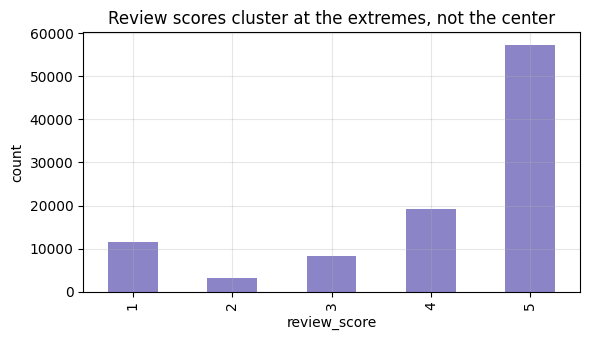

In [7]:
fig, ax = plt.subplots(figsize=(6, 3.5))
tables["order_reviews"]["review_score"].value_counts().sort_index().plot(kind="bar", ax=ax, color="#8B85C7")
ax.set_xlabel("review_score")
ax.set_ylabel("count")
ax.set_title("Review scores cluster at the extremes, not the center")
plt.tight_layout()
plt.show()

## Next

`02_features.ipynb` builds the seller-order pair table and the full seller-level feature matrix from these raw tables.